In [2]:
# Load data and inspect the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('/content/bmw.csv')

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  
(10781, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax      

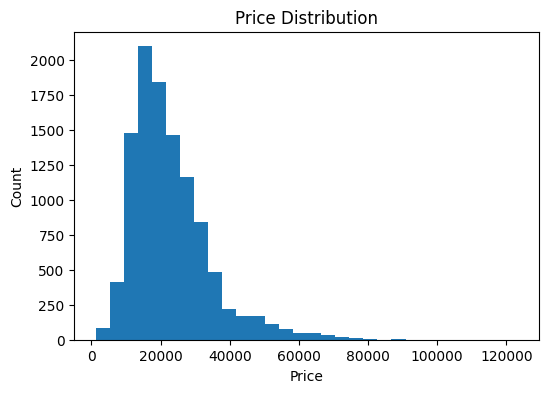

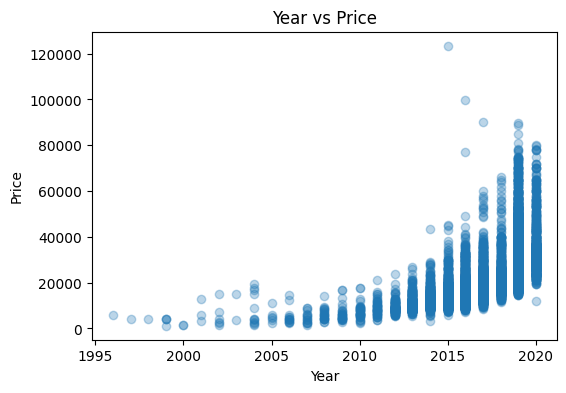

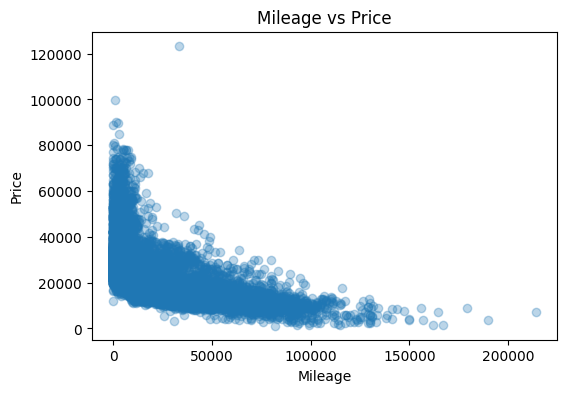

In [3]:
# Visualize price and key relationships
plt.figure(figsize=(6,4))
plt.hist(df['price'], bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['year'], df['price'], alpha=0.3)
plt.title('Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['mileage'], df['price'], alpha=0.3)
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [4]:
# Prepare features and target
X = df.drop('price', axis=1)
y = df['price']

cat_cols = ['model', 'transmission', 'fuelType']
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

In [5]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
# Encode categorical variables
pre = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)])

In [7]:
# Train a linear regression model
lr = Pipeline([
    ('pre', pre),
    ('model', LinearRegression())])

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('Linear Regression')
print('MAE:', mean_absolute_error(y_test, lr_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, lr_pred)))
print('R2:', r2_score(y_test, lr_pred))

Linear Regression
MAE: 3167.695713493995
RMSE: 4600.507254451193
R2: 0.836332472789019


In [8]:
# Train a random forest model
rf = Pipeline([
    ('pre', pre),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest')
print('MAE:', mean_absolute_error(y_test, rf_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, rf_pred)))
print('R2:', r2_score(y_test, rf_pred))

Random Forest
MAE: 1607.0682875606544
RMSE: 2719.6544399884187
R2: 0.9428023042772635


In [9]:
# Compare model performance
result = pd.DataFrame({
    'model': ['Linear Regression', 'Random Forest'],
    'MAE': [mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)) ],
    'R2': [r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)]})

print(result)

               model          MAE         RMSE        R2
0  Linear Regression  3167.695713  4600.507254  0.836332
1      Random Forest  1607.068288  2719.654440  0.942802


In [10]:
# Predict the price of one sample car
new_car = pd.DataFrame({'model': ['3 Series'],
    'year': [2018],
    'transmission': ['Automatic'],
    'mileage': [30000],
    'fuelType': ['Diesel'],
    'tax': [145],
    'mpg': [55.4],
    'engineSize': [2.0]})

pred_price = rf.predict(new_car)[0]
print('Predicted price:', round(pred_price, 2))

Predicted price: 19165.88
